# Investigating parameters effects on Sensitivity of the OGGM Mass Balance and Runoff Models

In this notebook we will explore the sensitivity of OGGM's mass-balance and runoff models using SAFE. We will focus on the three parameters: melt factor, precipitation factor and temperature bias.

We will start by applying one-at-a-time sensitivity analysis to get a feel for how much each parameter affects the model and output. We will then consider the uncertainty of these sensitivities and work to quantify them.

## Sensitivity Analysis with the OGGM Mass Balance Model

We will apply sensitivity analysis in the following order to investigate our model behaviour:

1. **One-at-a-time**: We will apply one-at-a-time analysis , in which we change one parameter at a time and see how the mass balance changes in accordance. To show this, we will plot an interactive mass balance time series with toggles, where the parameter values can be changed within their default boundaries.
2. **Global sensitivity analysis**: Here we will use AAT sampling to randomly sample a combination of the 3 parameters and investigate the sensitivity in the following ways
    a. Qualitative - scatter plots
    b. Quantitative - RSA and bootstrapping

This will be applied first to the mass balance model in the OGGM, and then to the runoff model in the OGGM.

First we install the packages we require from both OGGM and SAFE.

In [10]:
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
import scipy.stats as st

import oggm
from oggm import cfg, utils, workflow
from oggm.core import massbalance
from oggm.utils._funcs import rmsd
from oggm import tasks

# Install python package for interactive visualisation and import required functions:
%pip install -q ipywidgets
from ipywidgets import interact

# Install SAFE package and import required functions
%pip install SAFEpython

import xarray as xr
import safepython.PAWN as PAWN # Module to calculate PAWN sensitivity indices
import safepython.RSA_thres as RSA_tr # Module that implements RSA
from safepython.model_execution import model_execution # Module to execute the model
from safepython.sampling import AAT_sampling # Functions to perform the input sampling
from safepython.util import aggregate_boot # Functions to perform bootstrapping


Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


Now prepare to load the glacier dierectories from the OGGM.

In [11]:
cfg.initialize(logging_level='WARNING')
cfg.PATHS['working_dir'] = utils.gettempdir(dirname='OGGM-calib-ro', reset=True)
cfg.PARAMS['border'] = 10
cfg.PARAMS['store_model_geometry'] = True
oggm.cfg.PARAMS['min_ice_thick_for_length'] = 1  # a glacier is when ice thicker than 1m

2026-01-13 16:14:01: oggm.cfg: Reading default parameters from the OGGM `params.cfg` configuration file.
2026-01-13 16:14:01: oggm.cfg: Multiprocessing switched OFF according to the parameter file.
2026-01-13 16:14:01: oggm.cfg: Multiprocessing: using all available processors (N=22)
2026-01-13 16:14:01: oggm.cfg: PARAMS['border'] changed from `80` to `10`.
2026-01-13 16:14:01: oggm.cfg: PARAMS['store_model_geometry'] changed from `False` to `True`.
2026-01-13 16:14:01: oggm.cfg: PARAMS['min_ice_thick_for_length'] changed from `0.0` to `1`.


We start from a well known glacier in the Austrian Alps, Hintereisferner. But you can choose any other glacier, e.g. from [this list](https://github.com/OGGM/oggm-sample-data/blob/master/wgms/rgi_wgms_links_20220112.csv)

In [12]:
# Hintereisferner
rgi_id = 'RGI60-11.00897'

# We pick the elevation-bands glaciers because they run a bit faster - but they create more step changes in the area outputs
base_url = 'https://cluster.klima.uni-bremen.de/~oggm/gdirs/oggm_v1.6/L3-L5_files/2023.3/elev_bands/W5E5_spinup'
gdir_hef = workflow.init_glacier_directories([rgi_id], from_prepro_level=4, prepro_border=160, prepro_base_url=base_url)[0]

2026-01-13 16:14:03: oggm.workflow: init_glacier_directories from prepro level 4 on 1 glaciers.
2026-01-13 16:14:03: oggm.workflow: Execute entity tasks [gdir_from_prepro] on 1 glaciers


# 1 - One-at-a-time Sensitivity Analysis

We have loaded all required packages, so now we need to create a runner for the OGGM. To do this, we will set the 3 mass balance parameters to some tentative values, run the model and plot the resulting runoff timeseries. We can then change the parameter values one-at-a-time and look at how this changes the model predictions.

Since we have WGMS observed data here, we will use some fit-to-data metrics to compare the difference in mean, standard deviation and RMSD between the simulated and observed mass balance values.

In [13]:
mbdf = gdir_hef.get_ref_mb_data().loc[2000:2019] # WGMS data for HEF

def oat_oggm_runner(sample_row):
    
    # Set the parameter values that are being sampled
    melt_f, prcp_fac, temp_bias = sample_row

    # Running the model with the given parameters (without calibration which would alter them again)
    mbmod = massbalance.MonthlyTIModel(gdir_hef, melt_f=float(melt_f), prcp_fac=float(prcp_fac), temp_bias=float(temp_bias)) # Monthly TI model
    fls = gdir_hef.read_pickle('inversion_flowlines') # Read flowlines
    mbdf['mod_mb'] = mbmod.get_specific_mb(fls=fls, year=mbdf.index) # Compute modelled mass balance

    # In-situ mass balance for comparison
    mbdf['in_situ_mb'] = gdir_hef.get_ref_mb_data().loc[2000:2019]['ANNUAL_BALANCE']

    # Calculate the goodness-of-fit metrics
    mean_diff = np.array(mbdf['mod_mb'].mean() - mbdf['in_situ_mb'].mean())
    std_diff = np.array(mbdf['mod_mb'].std() - mbdf['in_situ_mb'].std())
    rmsd_ = np.array(rmsd(mbdf['mod_mb'], mbdf['in_situ_mb']))

    return mbdf['mod_mb'], mean_diff, std_diff, rmsd_


We will now plot our results, the parameter values can be changed one-at-a-time via a toggle on the graph below.

In [ ]:
# Define interactive visualisation function to set the parameters to some tentative values, 
# run the model and plot the resulting runoff time series

def oat_function(melt_f = 5.0, prcp_fac = 3.4, temp_bias = 0.0):
    # Create parameter array
    param = np.array([melt_f, prcp_fac, temp_bias])
    
    # Run the model with the given parameters, here we are interested in the modelled mass balance time series
    mb,_,_, _ = oat_oggm_runner(param)

    # Plot the results
    plt.figure(figsize=[15,3])
    plt.plot(mb, label='sim', color='k')
    mbdf['in_situ_mb'] = gdir_hef.get_ref_mb_data().loc[2000:2019]['ANNUAL_BALANCE']
    plt.plot(mbdf['in_situ_mb'], color=[0.7,0.7,0.7], label='obs')
    plt.ylabel('Specific mass balance (mm w.e.)')
    plt.xlabel('Year')
    plt.legend()
    plt.show();

# Create interactive plot, the toggles will change the parameter values 
interact(oat_function,
         melt_f = (1.5, 17.0, 0.1),
         prcp_fac = (0.1, 10.0, 0.1),
         temp_bias = (-15.0, 15.0, 0.1));



interactive(children=(FloatSlider(value=5.0, description='melt_f', max=17.0, min=1.5), FloatSlider(value=3.4, …

The above graph shows the effects that moving each of the parameters has to the mass balance time series.

# GSA - Global Sensitvity Analysis

We will now explore the sensitivity with a global sensitivity analysis. We will create a runner for the OGGM that calculates the mass balance values based off of the parameters sampled. We will be using AAT Sampling from SAFE to perform global sampling.

This method will be creating Monte Carlo Simulations, we will plot the mass balance time series resulting from the Monte Carlo simulations and analyse the results.

In [15]:
mbdf = gdir_hef.get_ref_mb_data().loc[2000:2019] # WGMS data for HEF
def oggm_runner(sample_row):

    # Set the parameter values
    melt_f, prcp_fac, temp_bias = sample_row
    cfg.PARAMS['melt_f'] = float(melt_f)
    cfg.PARAMS['prcp_fac'] = float(prcp_fac)
    cfg.PARAMS['temp_bias'] = float(temp_bias)
    
    # Running the model with the given parameters (without calibration which would alter them again)
    mbmod = massbalance.MonthlyTIModel(gdir_hef, melt_f=melt_f, prcp_fac=prcp_fac, temp_bias=temp_bias)
    fls = gdir_hef.read_pickle('inversion_flowlines') # Read flowlines
    mbdf['mod_mb'] = mbmod.get_specific_mb(fls=fls, year=mbdf.index) # Compute modelled mass balance
    mbdf['in_situ_mb'] = gdir_hef.get_ref_mb_data().loc[2000:2019]['ANNUAL_BALANCE'] # In-situ mass balance for comparison

    return np.array([mbdf['mod_mb']]) # Return modelled mass balance time series only


### Running Monte Carlo Simulations

In [16]:
X_labels = ['melt_f', 'prcp_fac', 'temp_bias']
M = len(X_labels)

distr_fun = st.uniform # Uniform distribution for all parameters
x_min = np.array([1.5, 0.1, -15.0]) # Minimum values for each parameter
x_max = np.array([17.0, 10.0, 15.0]) # Maximum values for each parameter

distr_par = [np.nan] * M
for i in range(M):
    distr_par[i] = [x_min[i], x_max[i] - x_min[i]]
samp_strat = 'lhs' 

N = 2000 # Number of samples
X = AAT_sampling(samp_strat, M, distr_fun, distr_par, N) # Generate the samples

QQ  = model_execution(oggm_runner, X) # Execute the model for all samples

# Calculate the goodness-of-fit metrics
mean_diff = np.array(mbdf['mod_mb'].mean() - mbdf['in_situ_mb'].mean()) # Calculate mean difference
std_diff = np.array(mbdf['mod_mb'].std() - mbdf['in_situ_mb'].std()) # Calculate standard deviation difference
rmsd_ = np.array(rmsd(mbdf['mod_mb'], mbdf['in_situ_mb'])) # Calculate RMSD

YY = np.nan * np.ones((N, 3))

for i, x in enumerate(QQ):
    YY[i,0] = x.mean() - mbdf['in_situ_mb'].mean()
    YY[i,1] = x.std() - mbdf['in_situ_mb'].std()
    YY[i,2] = rmsd(x, mbdf['in_situ_mb'])

2026-01-13 16:14:51: oggm.cfg: PARAMS['melt_f'] changed from `5.0` to `10.788199834373934`.
2026-01-13 16:14:51: oggm.cfg: PARAMS['temp_bias'] changed from `-9.872581215541366` to `-2.4421180767651958`.
2026-01-13 16:14:51: oggm.cfg: PARAMS['melt_f'] changed from `10.788199834373934` to `6.494311662914777`.
2026-01-13 16:14:51: oggm.cfg: PARAMS['prcp_fac'] changed from `1.0369245679174683` to `0.8265860152816348`.
2026-01-13 16:14:51: oggm.cfg: PARAMS['temp_bias'] changed from `-2.4421180767651958` to `-7.380690554257329`.
2026-01-13 16:14:51: oggm.cfg: PARAMS['melt_f'] changed from `6.494311662914777` to `5.170282092541967`.
2026-01-13 16:14:51: oggm.cfg: PARAMS['prcp_fac'] changed from `0.8265860152816348` to `5.596744031841341`.
2026-01-13 16:14:51: oggm.cfg: PARAMS['temp_bias'] changed from `-7.380690554257329` to `-3.468188149177182`.
2026-01-13 16:14:51: oggm.cfg: PARAMS['melt_f'] changed from `5.170282092541967` to `12.552492284800396`.
2026-01-13 16:14:51: oggm.cfg: PARAMS['prc

Plotting the Monte Carlo simulation results and comparison with the observed data.

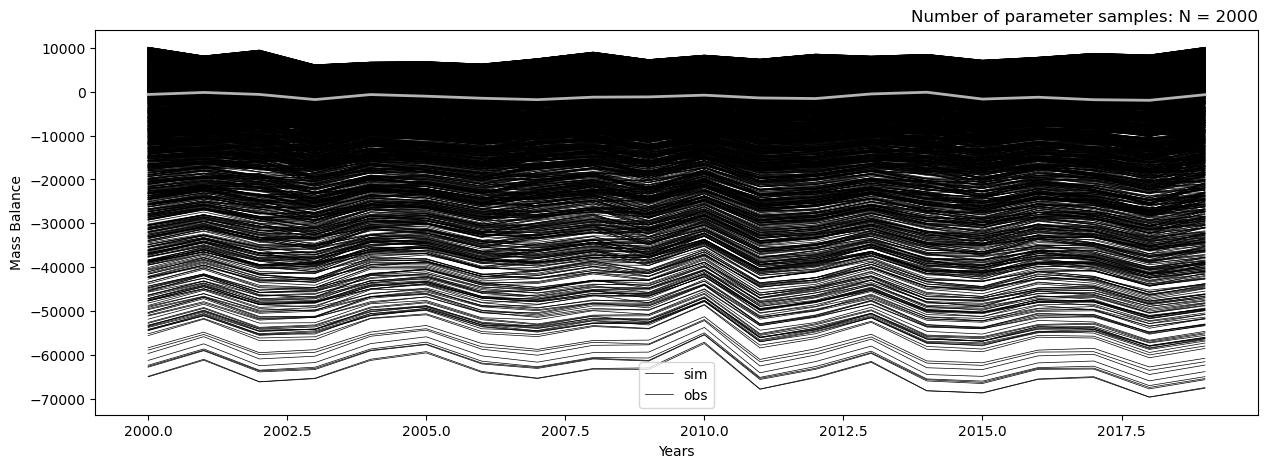

In [17]:
# Plot Monte Carlo (MC) simulations results and compare with data:
plt.figure(figsize=[15,5])
plt.plot(mbdf['in_situ_mb'].index.values, np.transpose(QQ), 'k', linewidth = 0.5)
plt.plot(mbdf['in_situ_mb'], color=[0.7,0.7,0.7], linewidth=2)
plt.ylabel('Mass Balance'); plt.xlabel('Years')
plt.legend(['sim', 'obs'])
plt.title("Number of parameter samples: N = %d" % N, loc='right')
plt.show()

We can see from the samples that the mass balance is greatly affected by altering the parameters between their given ranges. The lower mass balances seem to be more sparse, with a more significant clustering towards the higher mass-balances. The observed mass-balance is closer towards the higher mass-balance end of the spectrum, towards 0. 

### Scatter plot of the fit-to-data metrics

We will now plot a scatter plot of the fit-to-data metrics, this will show us the relationship between the metrics created from our Monte Carlo simulations.

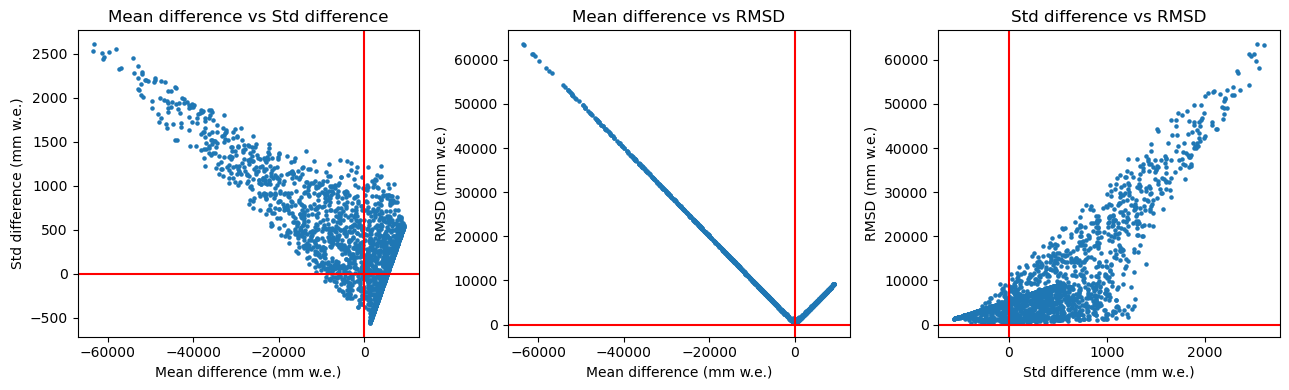

In [18]:
plt.figure(figsize=[13,4])
plt.subplot(1,3,1), plt.scatter(YY[:,0], YY[:,1], s=5), plt.title('Mean difference vs Std difference'), plt.xlabel('Mean difference (mm w.e.)'), plt.ylabel('Std difference (mm w.e.)'),
plt.axvline(x=0, color='r'), plt.axhline(y=0, color='r')
plt.gca().locator_params(axis='x', nbins=6)

plt.subplot(1,3,2), plt.scatter(YY[:,0], YY[:,2], s=5), plt.title('Mean difference vs RMSD'), plt.xlabel('Mean difference (mm w.e.)'), plt.ylabel('RMSD (mm w.e.)')
plt.axvline(x=0, color='r'), plt.axhline(y=0, color='r')
plt.gca().locator_params(axis='x', nbins=6)

plt.subplot(1,3,3), plt.scatter(YY[:,1], YY[:,2], s=5), plt.title('Std difference vs RMSD'), plt.xlabel('Std difference (mm w.e.)'), plt.ylabel('RMSD (mm w.e.)')
plt.axvline(x=0, color='r'), plt.axhline(y=0, color='r')
plt.gca().locator_params(axis='x', nbins=6)

plt.tight_layout()
plt.show()

# The red lines show the target of having zero differences in the mean, standard deviation and RMSD.
# TODO: Would absolute differences be better than the raw ones?

The red lines show the target values of our differences, ideally we would want our differences to be 0 and to match the observations as closely as possible.

It can be seen here that all of our fit-to-data metrics are correlated.

## Scatter plot for the parameters against the fit-to-data metrics

Now we can plot the scatter plots for each parameter against each metric, this will help visualise the sensitivities for the mass balance.

In [19]:

Y_Labels = ['Mean Difference', 'Std Difference', 'RMSD']

def scatter_function(metric='Mean Difference'):
    if metric == 'Mean Difference':
        j = 0
    elif metric == 'Std Difference':
        j = 1  
    elif metric == 'RMSD':
        j = 2
    plt.figure(figsize=[18,3])
    for i in range(M):
        plt.subplot(1,M,i+1)
        plt.plot(X[:, i], YY[:,j], '.', markerfacecolor="white", markeredgecolor="grey")        
        if i == 0:
            plt.ylabel(Y_Labels[j])
        else:
            plt.yticks([])       
        plt.xlabel(X_labels[i])       
    plt.show()

interact(scatter_function,  metric = Y_Labels);

interactive(children=(Dropdown(description='metric', options=('Mean Difference', 'Std Difference', 'RMSD'), va…

### Distribution of the model outputs

Now looking at the distribution of the model outputs, here this is the goodness-of-fit parameters.

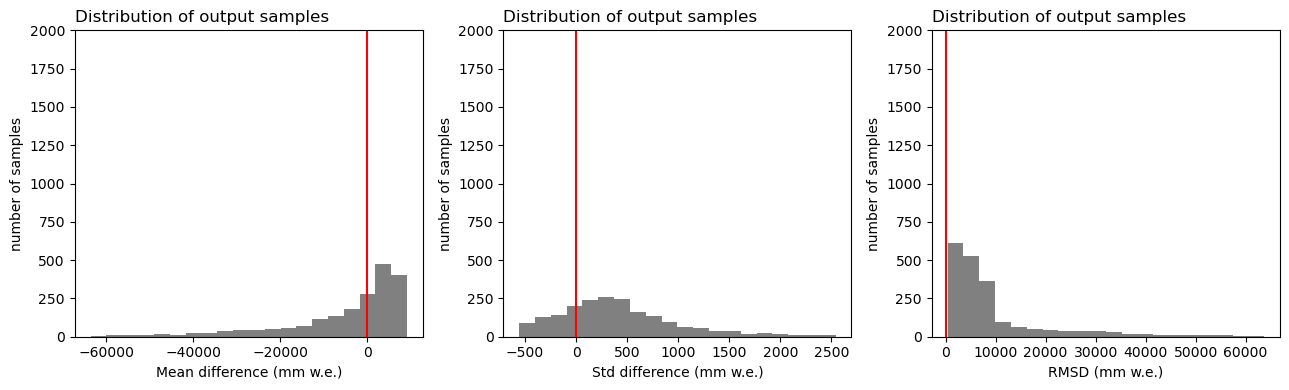

In [55]:
Y_Labels = ['Mean difference (mm w.e.)', 'Std difference (mm w.e.)', 'RMSD (mm w.e.)', 'Mean & Std difference jointly']

plt.figure(figsize=[13,4])
plt.subplot(1,3,1), plt.title('Distribution of output samples', loc='left'), plt.hist(YY[:,0], bins=20, color='grey');
plt.axvline(x=0, color='r'), plt.ylim((0,N)), plt.ylabel('number of samples'), plt.xlabel(Y_Labels[0])

plt.subplot(1,3,2), plt.title('Distribution of output samples', loc='left'), plt.hist(YY[:,1], bins=20, color='grey');
plt.axvline(x=0, color='r'), plt.ylim((0,N)), plt.ylabel('number of samples'), plt.xlabel(Y_Labels[1])

plt.subplot(1,3,3), plt.title('Distribution of output samples', loc='left'), plt.hist(YY[:,2], bins=20, color='grey');
plt.axvline(x=0, color='r'), plt.ylim((0,N)), plt.ylabel('number of samples'), plt.xlabel(Y_Labels[2])

plt.tight_layout()

Looking at our distributions of the output samples, the distributions are as follows:
1. Mean difference: Skewed distribition with a long tail (negative skew)
2. Std difference: Normal distribution
3. RMSD: Skewed distribution with a long tail (positive skew)

TODO: Does this mean we can use RSA vs PAWN?

# Calculating the Sensitivity Indices

Now we use the input-output samples generated in the previous step to calculate sensitivity indices using **Regional Sensitivity Analysis**. Calculating 3 sets of indices, each measuring the relative importance of the 3 input parameters.

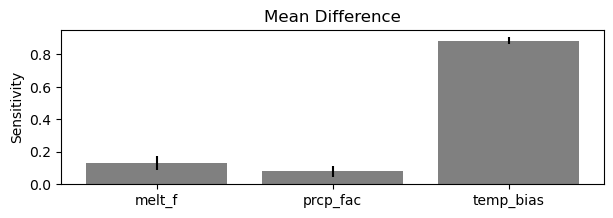

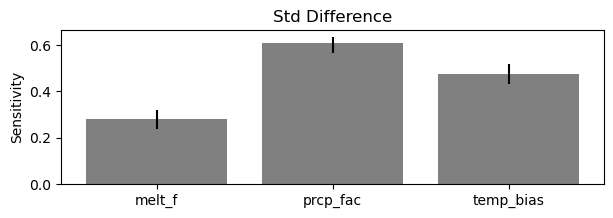

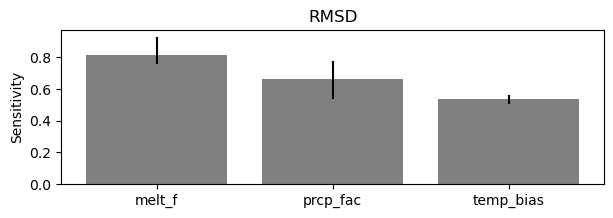

In [20]:
Nboot = 50 # Number of resamples used for bootstrapping

for i in range(3):
    if i==0:
        Y=YY[:,0]
        target=0
    if i==1:
        Y=YY[:,1]
        target=0
    if i==2:
        Y = YY[:,2]
        target = 500 # RMSD cannot be zero here? Minimum working number is around 500, minimum observed value is around 400.

    # plot:
    plt.figure(figsize=[7,2])
    mvd, _, _, idx = RSA_tr.RSA_indices_thres(X, Y, target, Nboot=Nboot)
    mvd_m, mvd_lb, mvd_ub = aggregate_boot(mvd) # shape (M,)
    yerr=np.c_[mvd_m-mvd_lb,mvd_ub-mvd_m].T
    plt.bar(range(len(mvd_m)), mvd_m, color='grey',yerr=yerr)
    plt.title(Y_Labels[i], loc='center'), plt.xticks(range(len(mvd_m)), X_labels), plt.ylabel('Sensitivity')
    plt.show()

## Extra Investigation: Relationship with temp_bias and other parameters to the fit-to-data outputs

Now checking, if the relationship with other parameters has been affected by the temp_bias, this is rather dominant in the differences of the mean. We can plot a colour map to check.

['Mean Difference', 'Std Difference', 'RMSD']


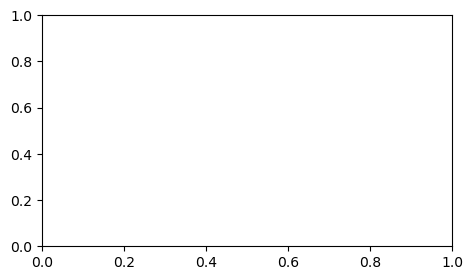

interactive(children=(Dropdown(description='metric', options=('Mean Difference', 'Std Difference', 'RMSD'), va…

In [21]:
temp_bias_index = 2

print(Y_Labels)

def scatter_function(metric='Mean difference (mm w.e.)'):
    if metric == 'Mean difference (mm w.e.)':
        j = 0
    elif metric == 'Std difference (mm w.e.)':
        j = 1  
    elif metric == 'RMSD (mm w.e.)':
        j = 2

    plt.figure(figsize=[18,3])
    for i in range(M):
        plt.subplot(1,M,i+1)
        # Use scatter with color mapped to temp_bias
        sc = plt.scatter(X[:, i], YY[:, j], c=X[:, temp_bias_index], cmap='coolwarm', edgecolors='grey')
        
        if i == 0:
            plt.ylabel(Y_Labels[j])
        else:
            plt.yticks([])       
        plt.xlabel(X_labels[i])       

        # Add colorbar only once
        if i == M-1:
            cbar = plt.colorbar(sc)
            cbar.set_label('Temp Bias (°C)')
    plt.show()

interact(scatter_function, metric=Y_Labels);


# Hydrological Response Metrics - Performance Metrics

Now looking at the hydrological response metrics we have avaliable in the OGGM, mean of runoff and mean of volume.

## One-at-a-time Sensitivity Analysis

In [14]:
import os

mbdf = gdir_hef.get_ref_mb_data().loc[2000:2019] # WGMS data for HEF

def oat_oggm_hydro_runner(gdir_hef, sample_row):
    
    # Set the parameter values that are being sampled
    melt_f, prcp_fac, temp_bias = sample_row

    cfg.PARAMS['melt_f'] = float(melt_f)
    cfg.PARAMS['prcp_fac'] = float(prcp_fac)
    cfg.PARAMS['temp_bias'] = float(temp_bias)

    # Setting the parameters in the glacier directory settings, run_with_hydro is a higher level function that reads them from there
    gdir_hef.settings['melt_f'] = float(melt_f) 
    gdir_hef.settings['prcp_fac'] = float(prcp_fac)
    gdir_hef.settings['temp_bias'] = float(temp_bias)

    # Running the model with the given parameters (without calibration which would alter them again)
    mbmod = massbalance.MonthlyTIModel(gdir_hef, melt_f=float(melt_f), prcp_fac=float(prcp_fac), temp_bias=float(temp_bias)) # Monthly TI model
    fls = gdir_hef.read_pickle('inversion_flowlines') # Read flowlines
    mbdf['mod_mb'] = mbmod.get_specific_mb(fls=fls, year=mbdf.index) # Compute modelled mass balance

    # file identifier where the model output is saved
    # Create unique file identifier based on parameters
    file_id = f'_hydro_mf{melt_f:.2f}_pf{prcp_fac:.2f}_tb{temp_bias:.2f}'

    # Delete old file if it exists to force recomputation
    old_file = gdir_hef.get_filepath('model_diagnostics', filesuffix=file_id)
    if os.path.exists(old_file):
        os.remove(old_file)

    # We are using the task run_with_hydro to store hydrological outputs along with the usual glaciological outputs
    tasks.run_with_hydro(gdir_hef,  # Run on the selected glacier
                     run_task=tasks.run_from_climate_data,  # which climate scenario? See following notebook for other examples
                     ys=2000,  # Period which we will average and constantly repeat
                     init_model_filesuffix='_spinup_historical',  # use the previous run as initial state
                     init_model_yr=2000,  # Start from spinup year 2000
                     store_monthly_hydro=True,  # Monthly ouptuts provide additional information
                     output_filesuffix=file_id);  # an identifier for the output file, to read it later

    with xr.open_dataset(gdir_hef.get_filepath('model_diagnostics', filesuffix=file_id)) as ds:
        # The last step of hydrological output is NaN (we can't compute it for this year)
        ds = ds.isel(time=slice(0, -1)).load()

    sel_vars = [v for v in ds.variables if 'month_2d' not in ds[v].dims]
    df_annual = ds[sel_vars].to_dataframe()

    # These summed variabels give the total runoff from the glacier
    runoff_vars = ['melt_off_glacier', 'melt_on_glacier','liq_prcp_off_glacier', 'liq_prcp_on_glacier']

    # Convert them to megatonnes (instead of kg)
    df_runoff = df_annual[runoff_vars] * 1e-9

    return df_runoff

In [15]:
# Define interactive visualisation function to set the parameters to some tentative values, 
# run the model and plot the resulting runoff time series
from ipywidgets import fixed, interact

def oat_hydro_function(gdir, melt_f = 5.0, prcp_fac = 3.4, temp_bias = 0.0):
    # Create parameter array
    param = np.array([melt_f, prcp_fac, temp_bias])
    
    # Run the model with the given parameters, here we are interested in the modelled mass balance time series
    df_runoff = oat_oggm_hydro_runner(gdir, param)

    # Plot the results
    plt.figure(figsize=[15,3])
    df_runoff.sum(axis=1).plot(label="sim")
    plt.ylabel('Runoff (Mt)')
    plt.xlabel('Year')
    plt.legend()

# Create interactive plot, the toggles will change the parameter values 
interact(oat_hydro_function,
         gdir = fixed(gdir_hef),
         melt_f = (1.5, 17.0, 0.1),
         prcp_fac = (0.1, 10.0, 0.1),
         temp_bias = (-15.0, 15.0, 0.1));

interactive(children=(FloatSlider(value=5.0, description='melt_f', max=17.0, min=1.5), FloatSlider(value=3.4, …

# GSA - Global Sensitivity Analysis

In [16]:
mbdf = gdir_hef.get_ref_mb_data().loc[2000:2019] # WGMS data for HEF

def oggm_hydro_runner(sample_row, gdir):

    # Set the values
    melt_f, prcp_fac, temp_bias = sample_row
    
    cfg.PARAMS['melt_f'] = float(melt_f)
    cfg.PARAMS['prcp_fac'] = float(prcp_fac)
    cfg.PARAMS['temp_bias'] = float(temp_bias)

    gdir.settings['melt_f'] = float(melt_f)
    gdir.settings['prcp_fac'] = float(prcp_fac)
    gdir.settings['temp_bias'] = float(temp_bias)

    gdir.settings['error_when_glacier_reaches_boundaries'] = False # TODO- Why does this need to be set for the hydro runs?


    # Running the model with the given parameters (without calibration which would alter them again)
    mbmod = massbalance.MonthlyTIModel(gdir_hef, melt_f=melt_f, prcp_fac=prcp_fac, temp_bias=temp_bias)
    fls = gdir_hef.read_pickle('inversion_flowlines') # Read flowlines
    mbdf['mod_mb'] = mbmod.get_specific_mb(fls=fls, year=mbdf.index) # Compute modelled mass balance

    # file identifier where the model output is saved
    # Create unique file identifier based on parameters
    file_id = f'_hydro_mf{melt_f:.2f}_pf{prcp_fac:.2f}_tb{temp_bias:.2f}'

    # Delete old file if it exists to force recomputation
    old_file = gdir_hef.get_filepath('model_diagnostics', filesuffix=file_id)
    if os.path.exists(old_file):
        os.remove(old_file)
        print(f"Deleted old file: {old_file}")

    # We are using the task run_with_hydro to store hydrological outputs along with the usual glaciological outputs
    tasks.run_with_hydro(gdir_hef,  # Run on the selected glacier
                     run_task=tasks.run_from_climate_data,  # which climate scenario? See following notebook for other examples
                     ys=2000,  # Period which we will average and constantly repeat
                     init_model_filesuffix='_spinup_historical',  # use the previous run as initial state
                     init_model_yr=2000,  # Start from spinup year 2000
                     store_monthly_hydro=True,  # Monthly ouptuts provide additional information
                     output_filesuffix=file_id);  # an identifier for the output file, to read it later

    with xr.open_dataset(gdir_hef.get_filepath('model_diagnostics', filesuffix=file_id)) as ds:
        # The last step of hydrological output is NaN (we can't compute it for this year)
        ds = ds.isel(time=slice(0, -1)).load()

    sel_vars = [v for v in ds.variables if 'month_2d' not in ds[v].dims]
    df_annual = ds[sel_vars].to_dataframe()

    # These summed variabels give the total runoff from the glacier
    runoff_vars = ['melt_off_glacier', 'melt_on_glacier','liq_prcp_off_glacier', 'liq_prcp_on_glacier']

    # Convert them to megatonnes (instead of kg)
    df_runoff = df_annual[runoff_vars] * 1e-9

    runoff = np.array(df_runoff.sum(axis=1))

    return runoff

### Running Monte Carlo Simulations

In [17]:
X_labels = ['melt_f', 'prcp_fac', 'temp_bias']
M = len(X_labels)
distr_fun = st.uniform # Uniform distribution for all parameters
x_min = np.array([1.5, 0.1, -15.0]) # Minimum values for each parameter
x_max = np.array([17.0, 10.0, 15.0]) # Maximum values for each parameter

distr_par = [np.nan] * M
for i in range(M):
    distr_par[i] = [x_min[i], x_max[i] - x_min[i]]
samp_strat = 'lhs' 
N = 1000 # Was 2000, TODO- change back to 2000? 1000 takes around 11 mins to run
X = AAT_sampling(samp_strat, M, distr_fun, distr_par, N) # Generate the samples

Volume

In [ ]:
# mbdf = gdir_hef.get_ref_mb_data().loc[2000:2019] # WGMS data for HEF

# def oggm_volume_runner(sample_row, gdir):

#     # Set the values
#     melt_f, prcp_fac, temp_bias = sample_row
    
#     cfg.PARAMS['melt_f'] = float(melt_f)
#     cfg.PARAMS['prcp_fac'] = float(prcp_fac)
#     cfg.PARAMS['temp_bias'] = float(temp_bias)

#     gdir.settings['melt_f'] = float(melt_f)
#     gdir.settings['prcp_fac'] = float(prcp_fac)
#     gdir.settings['temp_bias'] = float(temp_bias)

#     # gdir.settings['error_when_glacier_reaches_boundaries'] = False # TODO- Why does this need to be set for the hydro runs?

#     # Running the model with the given parameters (without calibration which would alter them again)
#     mbmod = massbalance.MonthlyTIModel(gdir_hef, melt_f=melt_f, prcp_fac=prcp_fac, temp_bias=temp_bias)
#     fls = gdir_hef.read_pickle('inversion_flowlines') # Read flowlines
#     mbdf['mod_mb'] = mbmod.get_specific_mb(fls=fls, year=mbdf.index) # Compute modelled mass balance

#     # 1) Apparent MB must be recomputed with the newly set parameters
#     tasks.apparent_mb_from_any_mb(gdir_hef)

#     # 2) Inversion: prepare and compute thickness / volume
#     tasks.prepare_for_inversion(gdir_hef)
#     tasks.mass_conservation_inversion(gdir_hef)

#     # 3) Read volume (m³) and convert to km³
#     try:
#         vol_m3 = tasks.get_inversion_volume(gdir_hef)  # returns total inversion volume
#     except Exception:
#         # Robust fallback: integrate over inversion flowlines
#         fls = gdir_hef.read_pickle('inversion_flowlines')
#         vol_m3 = sum(np.sum(fl.thick * fl.width_m * fl.dx) for fl in fls)

#     vol_km3 = np.array(float(vol_m3) / 1e9)

#     return vol_km3 # Volume in km³ of the glacier

In [19]:
QQ_runoff  = model_execution(oggm_hydro_runner, X, gdir_hef) # Execute the model for all samples
# QQ_volume  = model_execution(oggm_volume_runner, X, gdir_hef) # Execute the model for all samples

2026-01-13 10:08:44: oggm.cfg: PARAMS['melt_f'] changed from `1.8` to `6.617320590264304`.
2026-01-13 10:08:44: oggm.cfg: PARAMS['prcp_fac'] changed from `3.400000000000001` to `7.666581366941756`.
2026-01-13 10:08:44: oggm.cfg: PARAMS['temp_bias'] changed from `0.0` to `3.644553838365585`.


Deleted old file: /tmp/OGGM/OGGM-calib-ro/per_glacier/RGI60-11/RGI60-11.00/RGI60-11.00897/model_diagnostics_hydro_mf6.62_pf7.67_tb3.64.nc


2026-01-13 10:08:45: oggm.cfg: PARAMS['melt_f'] changed from `6.617320590264304` to `14.939025327333251`.
2026-01-13 10:08:45: oggm.cfg: PARAMS['prcp_fac'] changed from `7.666581366941756` to `8.983812884570831`.
2026-01-13 10:08:45: oggm.cfg: PARAMS['temp_bias'] changed from `3.644553838365585` to `-9.864951276825629`.
2026-01-13 10:08:46: oggm.cfg: PARAMS['melt_f'] changed from `14.939025327333251` to `2.354559643574003`.
2026-01-13 10:08:46: oggm.cfg: PARAMS['prcp_fac'] changed from `8.983812884570831` to `7.929677240143069`.
2026-01-13 10:08:46: oggm.cfg: PARAMS['temp_bias'] changed from `-9.864951276825629` to `4.084832075515269`.
2026-01-13 10:08:47: oggm.cfg: PARAMS['melt_f'] changed from `2.354559643574003` to `13.900033216315585`.
2026-01-13 10:08:47: oggm.cfg: PARAMS['prcp_fac'] changed from `7.929677240143069` to `1.2384257304297086`.
2026-01-13 10:08:47: oggm.cfg: PARAMS['temp_bias'] changed from `4.084832075515269` to `-12.94800456226703`.
2026-01-13 10:08:47: oggm.cfg: PA

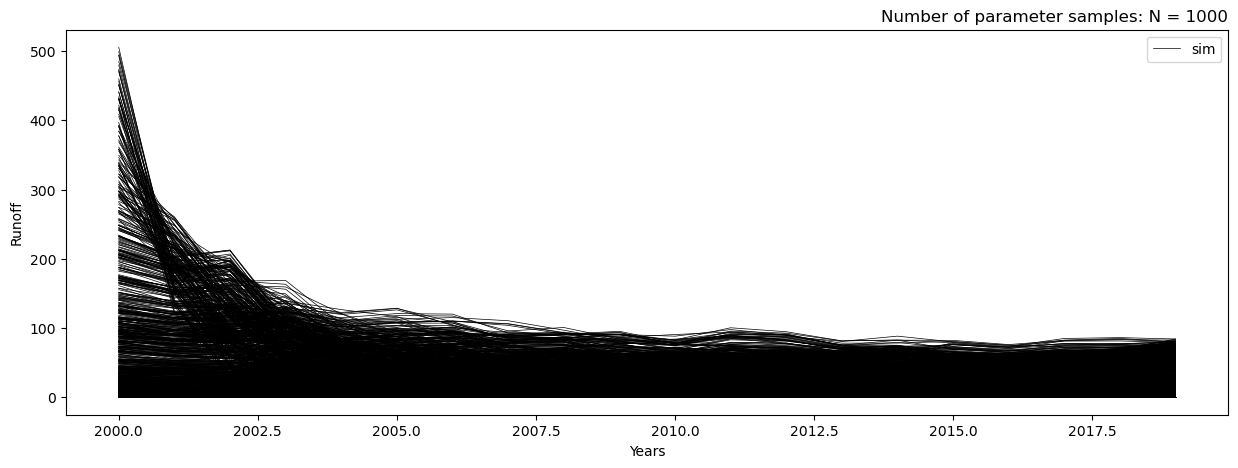

In [20]:
# Plot Monte Carlo (MC) simulations results for thr Runoff and compare with data:
plt.figure(figsize=[15,5])
plt.plot(mbdf.index.values, np.transpose(QQ_runoff), 'k', linewidth = 0.5)
plt.ylabel('Runoff'); plt.xlabel('Years')
plt.legend(['sim'])
plt.title("Number of parameter samples: N = %d" % N, loc='right')
plt.show()


## Sensitivity Analysis

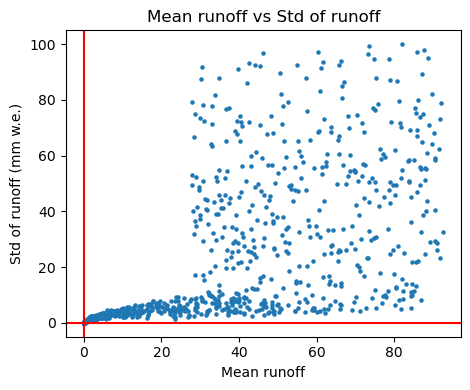

In [36]:
annual_mean_runoff = np.mean(QQ_runoff, axis=1) # Mean annual runoff for each sample
annual_std_runoff = np.std(QQ_runoff, axis=1) # Std annual runoff for each sample

plt.figure(figsize=[13,4])
plt.subplot(1,3,1), plt.scatter(annual_mean_runoff, annual_std_runoff, s=5), plt.title('Mean runoff vs Std of runoff'), plt.xlabel('Mean runoff'), plt.ylabel('Std of runoff (mm w.e.)'),
plt.axvline(x=0, color='r'), plt.axhline(y=0, color='r')
plt.gca().locator_params(axis='x', nbins=6)

# plt.subplot(1,3,2), plt.scatter(annual_mean_runoff, QQ_volume, s=5), plt.title('Mean runoff vs Volume'), plt.xlabel('Mean runoff'), plt.ylabel('Volume (km³)')
# plt.axvline(x=0, color='r'), plt.axhline(y=0, color='r')
# plt.gca().locator_params(axis='x', nbins=6)

plt.tight_layout()
plt.show()

# compare to x1, x2, x3, x4!!

# The red lines show the target of having zero differences in the mean, standard deviation and RMSD.
# TODO: Would absolute differences be better than the raw ones?

In [38]:
    # YY[i,0] = x.mean() - mbdf['in_situ_mb'].mean()
    # YY[i,1] = x.std() - mbdf['in_situ_mb'].std()
    # YY[i,2] = rmsd(x, mbdf['in_situ_mb'])
YY_hydro = np.nan * np.ones((N, 3))

for i, x in enumerate(QQ_runoff):
    YY_hydro[i,0] = np.mean(x)
    YY_hydro[i,1] = np.std(x)

Y_Labels = ['Mean Runoff', 'Std of Runoff']

def scatter_function(metric='Mean Runoff'):
    if metric == 'Mean Runoff':
        j = 0
    elif metric == 'Std of Runoff':
        j = 1  

    plt.figure(figsize=[18,3])
    for i in range(M):
        plt.subplot(1,M,i+1)
        plt.plot(X[:, i], YY_hydro[:,j], '.', markerfacecolor="white", markeredgecolor="grey")        
        if i == 0:
            plt.ylabel(Y_Labels[j])
        else:
            plt.yticks([])       
        plt.xlabel(X_labels[i])       
    plt.show()

interact(scatter_function,  metric = Y_Labels);

interactive(children=(Dropdown(description='metric', options=('Mean Runoff', 'Std of Runoff'), value='Mean Run…

In [43]:
temp_bias_index = 2

def scatter_function(metric='Mean Runoff'):
    if metric == 'Mean Runoff':
        j = 0
    elif metric == 'Std of Runoff':
        j = 1  

    plt.figure(figsize=[18,3])
    for i in range(M):
        plt.subplot(1,M,i+1)
        # Use scatter with color mapped to temp_bias
        sc = plt.scatter(X[:, i], YY_hydro[:, j], c=X[:, temp_bias_index], cmap='coolwarm', edgecolors='grey')
        
        if i == 0:
            plt.ylabel(Y_Labels[j])
        else:
            plt.yticks([])       
        plt.xlabel(X_labels[i])       

        # Add colorbar only once
        if i == M-1:
            cbar = plt.colorbar(sc)
            cbar.set_label('Temp Bias (°C)')
    plt.show()

interact(scatter_function, metric=Y_Labels);


interactive(children=(Dropdown(description='metric', options=('Mean Runoff', 'Std of Runoff'), value='Mean Run…

[0.12619781 0.10135114 0.98865905]


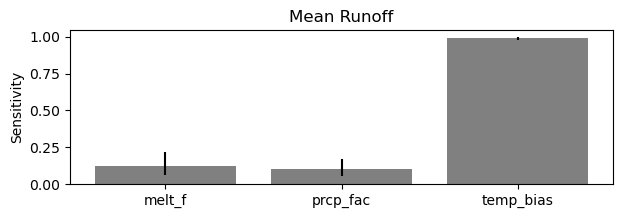

[0.17186501 0.12948139 0.97374024]


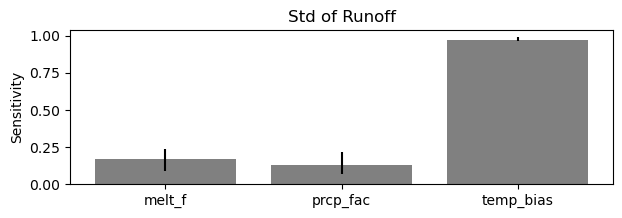

/home/chloe/micromamba/envs/oggm_env/lib/python3.11/site-packages/safepython/RSA_thres.py:303: UserWarning: Cannot find any output value below the threshold! Try increasing the threshold value
  warn('Cannot find any output value below the threshold! Try increasing the threshold value')
/home/chloe/micromamba/envs/oggm_env/lib/python3.11/site-packages/safepython/util.py:334: RuntimeWarning: Mean of empty slice
  S_m[j, :] = np.nanmean(S[j], axis=0) # bootstrap mean
/home/chloe/micromamba/envs/oggm_env/lib/python3.11/site-packages/safepython/util.py:337: UserWarning: Statistics were computed using 0 bootstrap resamples instead of 100
  warn('Statistics were computed using ' + '%d' % (np.sum(idx))+


IndexError: index 0 is out of bounds for axis 0 with size 0

<Figure size 700x200 with 0 Axes>

In [47]:
Nboot = 100 # Number of resamples used for bootstrapping
# Here fails when target is 0 for mean and std runoff, so we set small values instead
# Need to decide on the target volume?

for i in range(3):
    if i==0:
        Y=YY_hydro[:,0]
        target=0.1
    if i==1:
        Y=YY_hydro[:,1]
        target=0.1
    if i==2:
        Y = YY_hydro[:,2]
        target = 0.
    # plot:
    plt.figure(figsize=[7,2])
    mvd, _, _, idx = RSA_tr.RSA_indices_thres(X, Y, target, Nboot=Nboot)
    mvd_m, mvd_lb, mvd_ub = aggregate_boot(mvd) # shape (M,)
    print(mvd_m)
    yerr=np.c_[mvd_m-mvd_lb,mvd_ub-mvd_m].T
    plt.bar(range(len(mvd_m)), mvd_m, color='grey',yerr=yerr)
    plt.title(Y_Labels[i], loc='center'), plt.xticks(range(len(mvd_m)), X_labels), plt.ylabel('Sensitivity')
    plt.show()